In [33]:
import os
import shutil
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
image_path = Path("../../data/brisc2025/segmentation_task/train/images")
mask_path = Path("../../data/brisc2025/segmentation_task/train/masks")

In [35]:
image = Image.open(image_path / os.listdir(image_path)[0]).convert("L")
mask = Image.open(mask_path / os.listdir(mask_path)[0]).convert("L")

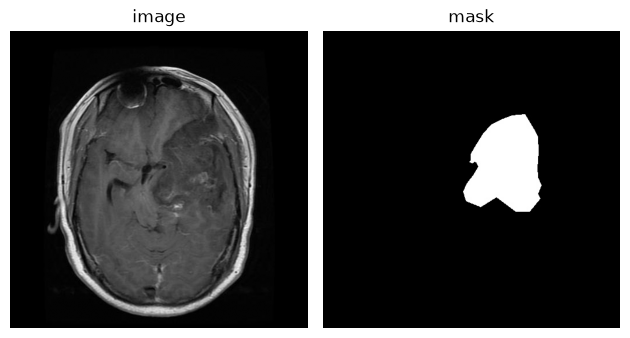

In [36]:
fig, axes = plt.subplots(1, 2)

for ax, img, img_label in zip(axes, [image, mask], ["image", "mask"]):
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(img_label)

fig.tight_layout()

In [37]:
df = pd.read_csv(image_path.parent.parent.parent / "manifest.csv")

df.head()

,relative_path,filename,task,split,index,tumor_code,tumor_label,plane_code,plane_label,sequence,is_mask,linked_image,width,height,file_size_bytes,sha256
0,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00001_gl_ax_t1.jpg,classification,test,1,gl,glioma,ax,axial,T1,False,NaN,512,512,25826,b513a83f68e486f45159b004d356782e78284014532151...
1,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00002_gl_ax_t1.jpg,classification,test,2,gl,glioma,ax,axial,T1,False,NaN,512,512,20982,5b4e4a0f482cb68955c340205d475f25c3a30718bd3b48...
2,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00003_gl_ax_t1.jpg,classification,test,3,gl,glioma,ax,axial,T1,False,NaN,512,512,13285,6fd1918b39e7a7f92fa5652d7802583f3251fed50a23ec...
3,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00004_gl_ax_t1.jpg,classification,test,4,gl,glioma,ax,axial,T1,False,NaN,512,512,26137,216b65a45d7effb4ebce1c9893f97d12449c9da777f818...
4,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00005_gl_ax_t1.jpg,classification,test,5,gl,glioma,ax,axial,T1,False,NaN,512,512,21709,c35734545021ab5a4f55fb87e08732e26fb16abe887927...


In [38]:
print(len(df))
df = df[df['relative_path'].astype(str).str.startswith("segmentation_task")]
print(len(df))

15586
9586


In [39]:
df.columns

Index(['relative_path', 'filename', 'task', 'split', 'index', 'tumor_code',
       'tumor_label', 'plane_code', 'plane_label', 'sequence', 'is_mask',
       'linked_image', 'width', 'height', 'file_size_bytes', 'sha256'],
      dtype='str')

In [40]:
df["is_mask"].value_counts()

is_mask
False    4793
True     4793
Name: count, dtype: int64

4793 .jpg images in total with their corresponding masks in .png

In [41]:
df[["width", "height"]].value_counts().to_dict()

{(512, 512): 9008,
 (256, 256): 60,
 (225, 225): 30,
 (442, 442): 16,
 (455, 500): 10,
 (554, 554): 10,
 (201, 251): 10,
 (200, 223): 8,
 (212, 237): 8,
 (210, 240): 8,
 (341, 395): 8,
 (213, 237): 6,
 (257, 307): 4,
 (228, 221): 4,
 (528, 581): 4,
 (295, 394): 4,
 (219, 234): 4,
 (206, 249): 4,
 (530, 526): 4,
 (472, 546): 4,
 (441, 427): 4,
 (507, 605): 4,
 (591, 650): 4,
 (300, 345): 4,
 (291, 340): 4,
 (318, 354): 4,
 (315, 341): 4,
 (278, 306): 4,
 (312, 401): 4,
 (300, 412): 4,
 (205, 251): 4,
 (204, 249): 4,
 (323, 342): 4,
 (369, 398): 4,
 (216, 216): 4,
 (351, 398): 4,
 (341, 372): 4,
 (273, 326): 4,
 (305, 337): 4,
 (304, 410): 4,
 (208, 243): 4,
 (341, 377): 4,
 (200, 252): 4,
 (480, 480): 4,
 (491, 624): 4,
 (224, 219): 4,
 (200, 235): 4,
 (209, 241): 4,
 (211, 239): 4,
 (215, 234): 4,
 (314, 358): 4,
 (214, 216): 4,
 (214, 235): 4,
 (213, 236): 4,
 (224, 216): 4,
 (338, 345): 4,
 (262, 308): 4,
 (306, 306): 4,
 (374, 370): 4,
 (201, 207): 4,
 (286, 356): 4,
 (290, 342): 4,

Since there are varying heights, widths and aspect ratios in the images, images will require center crop followed by resizing in transforms to bring them all to a uniform input size. 

In [42]:
df["tumor_label"].value_counts()

tumor_label
pituitary     3514
meningioma    3270
glioma        2802
Name: count, dtype: int64

three classes, one mask per image

# Create a customized segmentation-only csv with our own splits

Drop redundant columns and concat corresponding masks to images in the same row. 

In [43]:
df.columns

Index(['relative_path', 'filename', 'task', 'split', 'index', 'tumor_code',
       'tumor_label', 'plane_code', 'plane_label', 'sequence', 'is_mask',
       'linked_image', 'width', 'height', 'file_size_bytes', 'sha256'],
      dtype='str')

In [44]:
df = df.drop(['filename', 'task', 'split', 'index', 'tumor_code', 'plane_code', 'plane_label', 'sequence', 'width', 'height', 'file_size_bytes', 'sha256'], axis=1)
df = df[df["is_mask"]].copy()

len(df)

4793

In [45]:
df.columns

Index(['relative_path', 'tumor_label', 'is_mask', 'linked_image'], dtype='str')

In [46]:
df.rename(columns={"linked_image": "image_path", "relative_path": "mask_path","tumor_label": "tumor"}, inplace=True)
df.drop(['is_mask'], axis=1, inplace=True)

In [47]:
label_map = {
    'background': 0,
    'pituitary': 1,
    'meningioma': 2,
    'glioma': 3,
}

In [48]:
df = df[['image_path', 'mask_path', 'tumor']].copy()
df["label"] = df['tumor'].apply(lambda x: label_map[x])

In [49]:
print(df["label"].value_counts().to_dict())
print("total: ", int(df["label"].value_counts().sum()))

{1: 1757, 2: 1635, 3: 1401}
total:  4793


In [50]:
df.to_csv(image_path.parent.parent.parent / "segmentation_metadata.csv", index=False)

In [51]:
type(df)

pandas.DataFrame

In [52]:
from sklearn.model_selection import train_test_split

def split(csv, train=0.6, val=0.2, test=0.2, seed=42):
    assert abs(train + val + test - 1) < 1e-6, "Splits must sum up to 1.0."

    if not isinstance(csv, pd.DataFrame):
        df = pd.read_csv(csv)
    else:
        df = csv

    train_df, val_plus_test_df = train_test_split(
        df, 
        test_size=val+test,
        train_size=train,
        stratify=df["label"],
        random_state=seed
    )

    val_df, test_df = train_test_split(
        val_plus_test_df,
        test_size=test / (test + val),
        train_size=val / (test + val),
        stratify=val_plus_test_df["label"],
        random_state=seed
    )

    return train_df, val_df, test_df

In [53]:
df.iloc[0]["image_path"]

'segmentation_task\\test\\images\\brisc2025_test_00001_gl_ax_t1.jpg'